In [7]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.dates as mdates

# 设置科研绘图风格
plt.style.use('seaborn-v0_8-paper')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 100

print("Libraries imported and style set.")

Libraries imported and style set.


In [ ]:
# 读取数据文件
files = {
    'Raw': '../DataFormat/merged_cgm_data.csv',
    'Kalman': './kalman/kalman_filtered_cgm_data.csv',
    'S-G': './sg/sg_filtered_cgm_data.csv',
    'Butterworth': './butterworth/butterworth_filtered_cgm_data.csv'
}

dfs = {}
for name, file_path in files.items():
    if os.path.exists(file_path):
        print(f"Reading {name} data from: {file_path}")
        df = pd.read_csv(file_path)
        df['time'] = pd.to_datetime(df['time'])
        dfs[name] = df
    else:
        print(f"Warning: {file_path} not found. Please run the corresponding notebook first.")

if 'Raw' not in dfs:
    print("Error: Raw data not found!")
else:
    print("All datasets loaded successfully.")

Reading Raw data from: ../DataFormat/merged_cgm_data.csv
Reading Kalman data from: kalman_filtered_cgm_data.csv
Reading S-G data from: sg_filtered_cgm_data.csv
Reading Butterworth data from: butterworth_filtered_cgm_data.csv
All datasets loaded successfully.


In [9]:
# 合并数据以便绘图
# 以 Raw 数据为基准
if 'Raw' in dfs:
    merged_df = dfs['Raw'][['id', 'time', 'gl']].copy()
    
    if 'Kalman' in dfs:
        # 合并 Kalman 数据
        if 'gl_kalman' in dfs['Kalman'].columns:
            temp_kalman = dfs['Kalman'][['id', 'time', 'gl_kalman']]
            merged_df = pd.merge(merged_df, temp_kalman, on=['id', 'time'], how='inner')
    
    if 'S-G' in dfs:
        # 合并 S-G 数据
        if 'gl_sg' in dfs['S-G'].columns:
            temp_sg = dfs['S-G'][['id', 'time', 'gl_sg']]
            merged_df = pd.merge(merged_df, temp_sg, on=['id', 'time'], how='inner')
        
    if 'Butterworth' in dfs:
        # 合并 Butterworth 数据
        if 'gl_butter' in dfs['Butterworth'].columns:
            temp_butter = dfs['Butterworth'][['id', 'time', 'gl_butter']]
            merged_df = pd.merge(merged_df, temp_butter, on=['id', 'time'], how='inner')
        
    print(f"Merged data shape: {merged_df.shape}")
    print(merged_df.head())
else:
    print("Error: Raw data is missing, cannot proceed with base dataframe.")

Merged data shape: (101600, 6)
   id                time     gl   gl_kalman       gl_sg   gl_butter
0   2 2012-01-01 00:00:00  167.0  167.000000  169.746732  166.909051
1   2 2012-01-01 00:05:00  163.0  166.298969  162.297852  160.978605
2   2 2012-01-01 00:10:00  158.0  163.151082  155.290688  155.031165
3   2 2012-01-01 00:15:00  151.0  156.616025  148.809452  149.137821
4   2 2012-01-01 00:20:00  144.0  148.539769  142.938357  143.482466


Generating comparison plots for 10 subjects


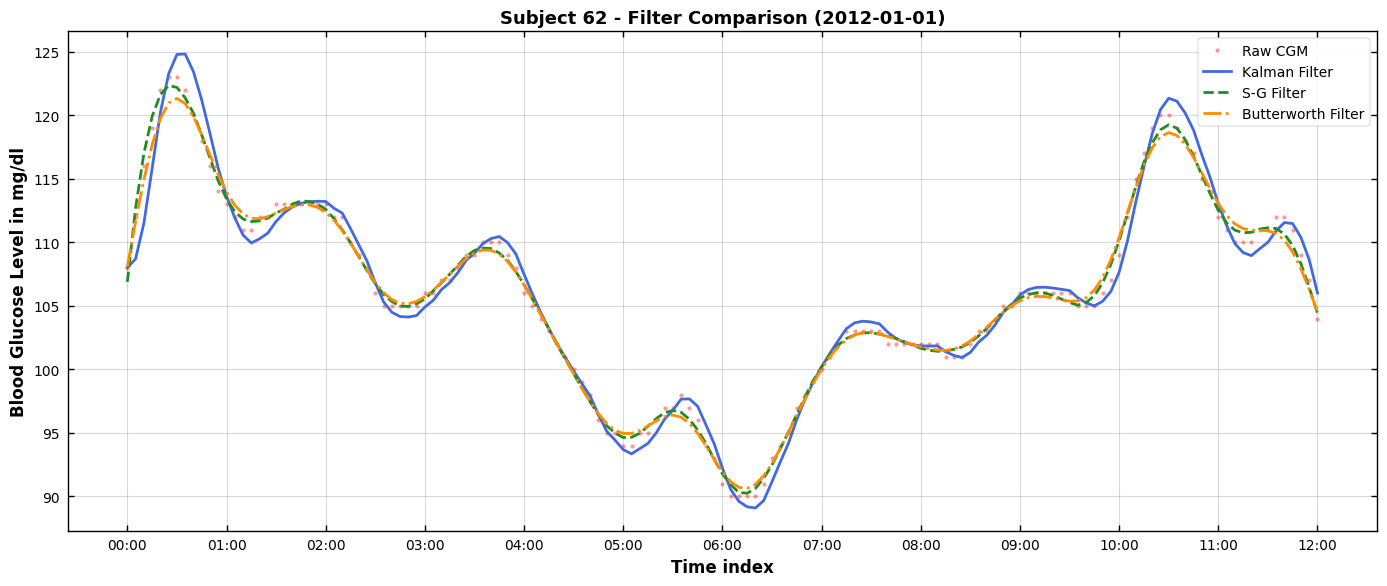

Comparison plot for Subject 62 generated.


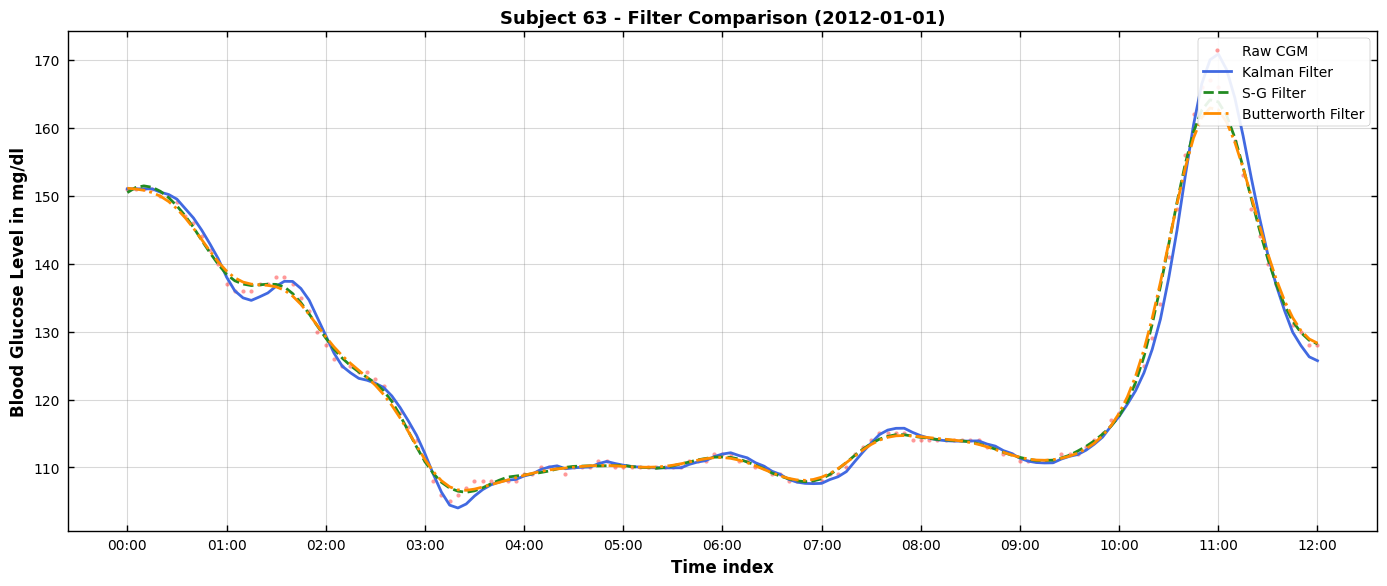

Comparison plot for Subject 63 generated.


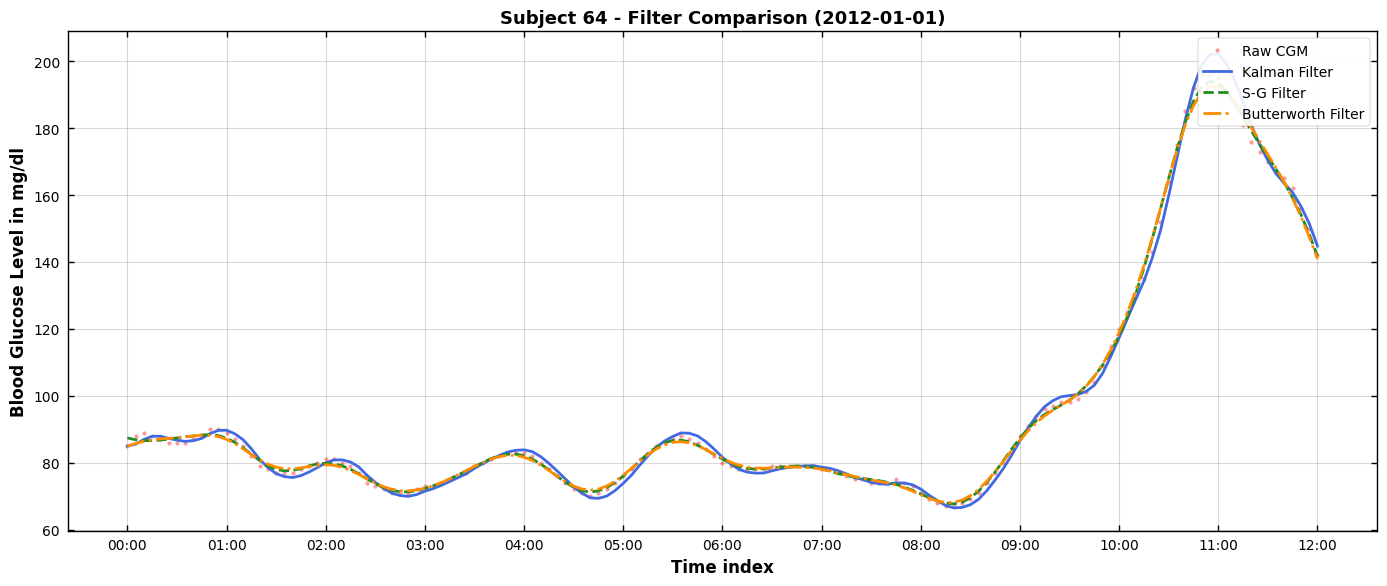

Comparison plot for Subject 64 generated.


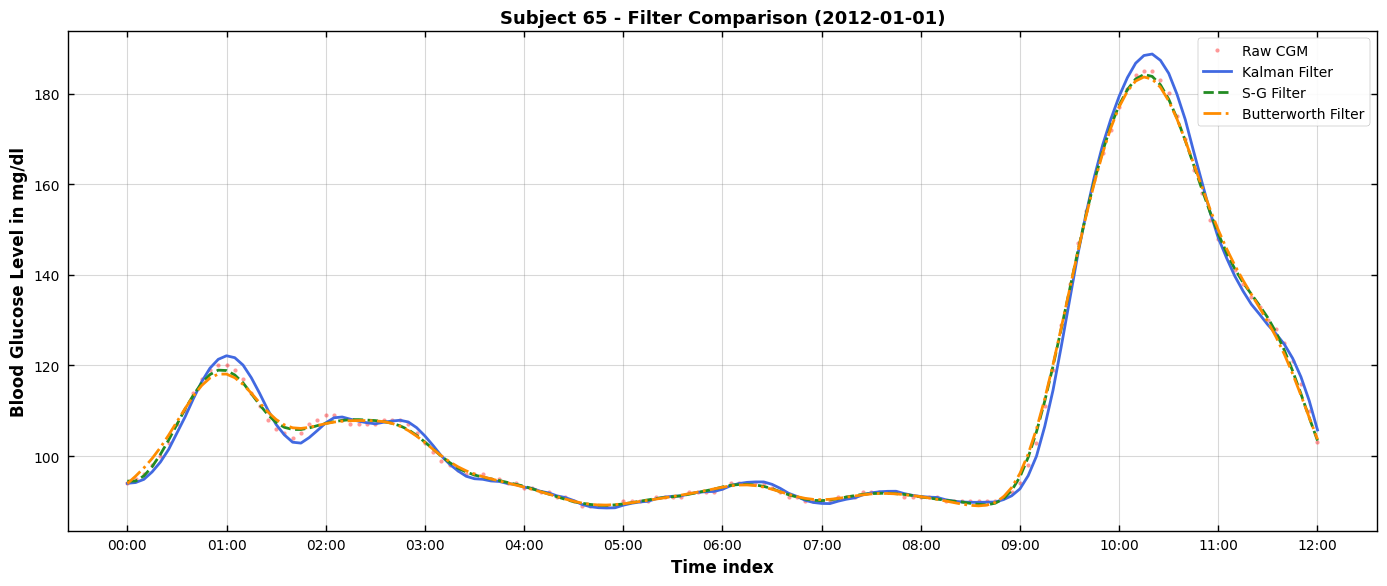

Comparison plot for Subject 65 generated.


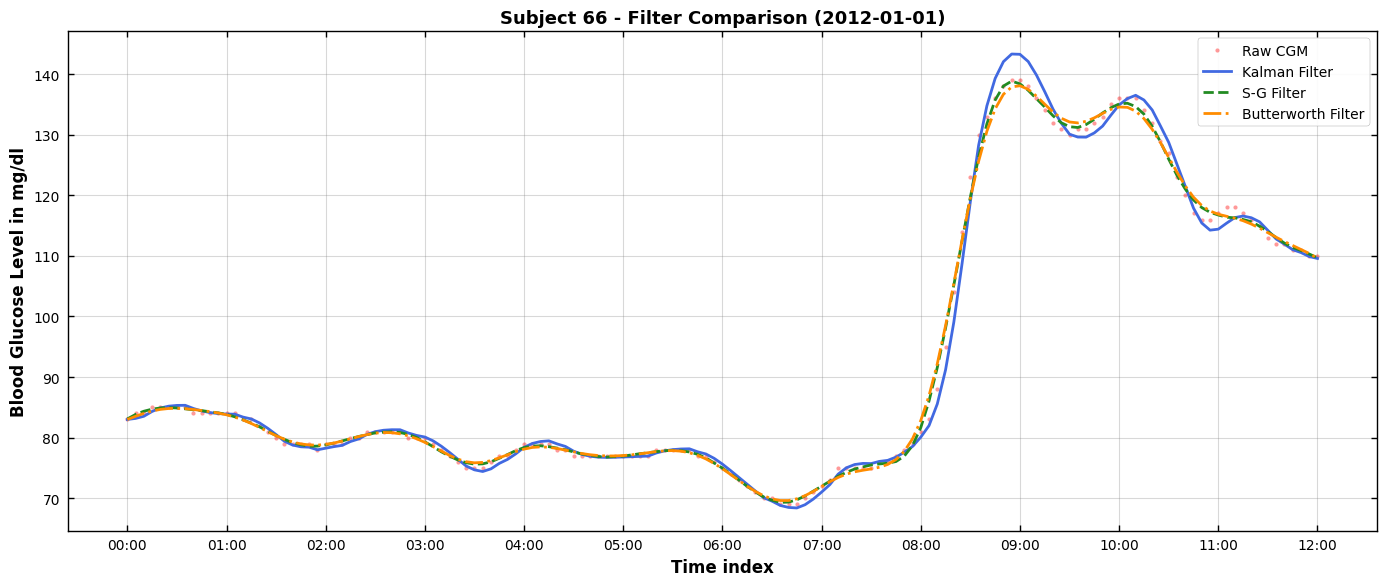

Comparison plot for Subject 66 generated.


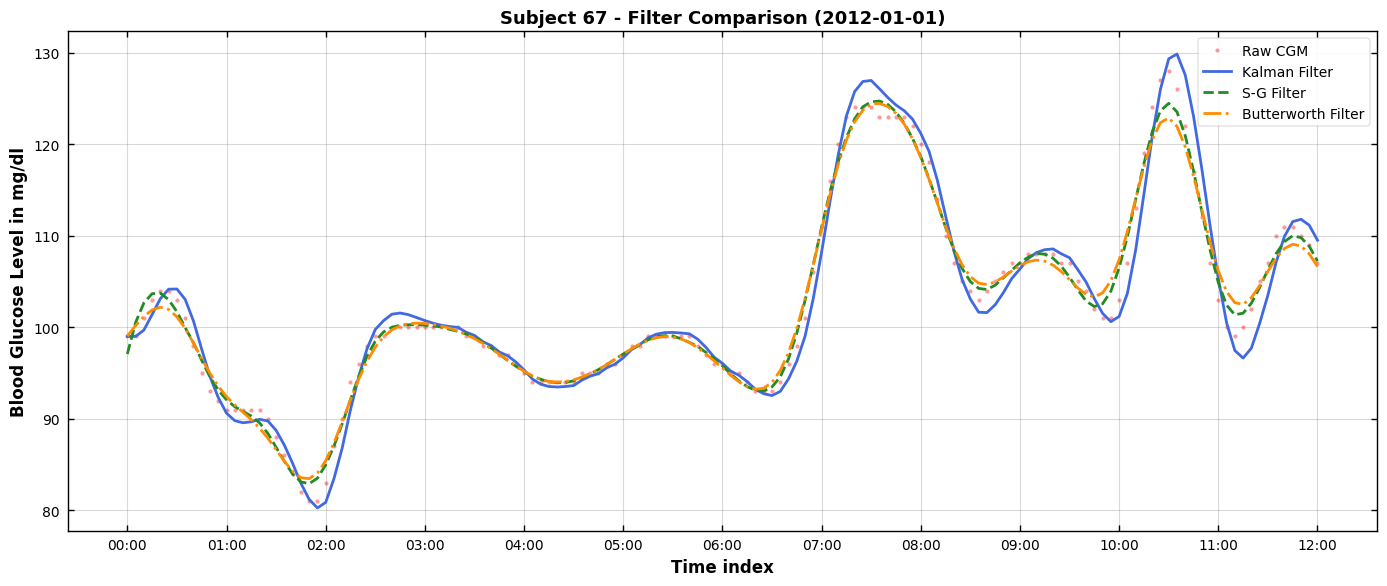

Comparison plot for Subject 67 generated.


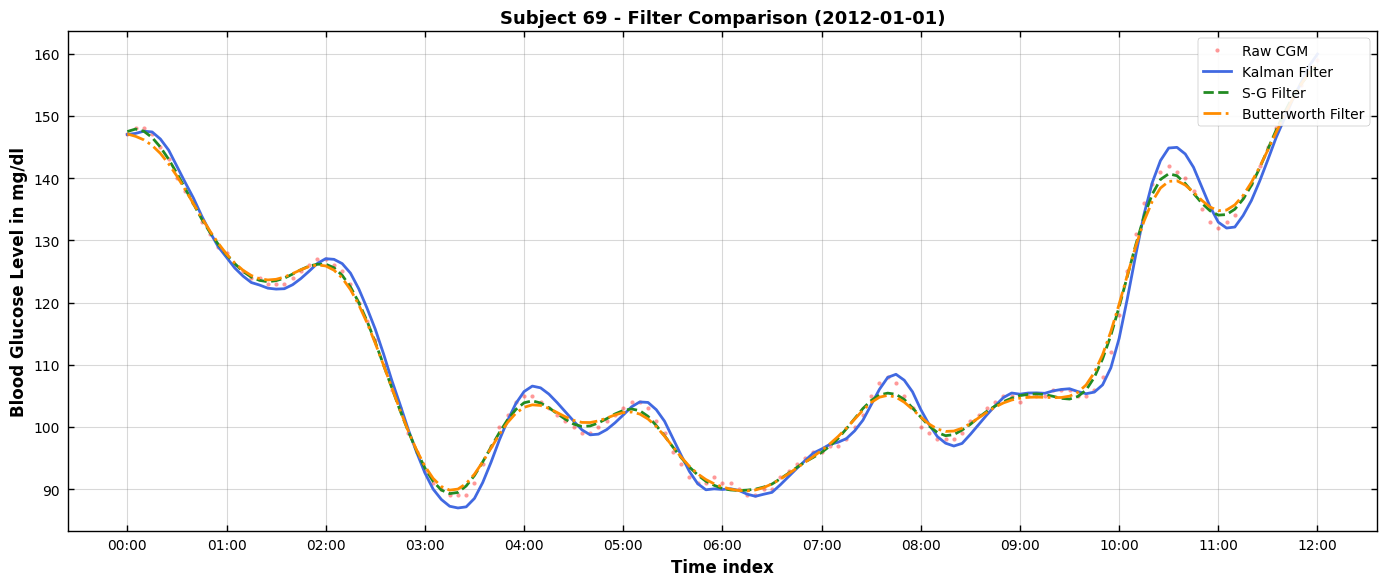

Comparison plot for Subject 69 generated.


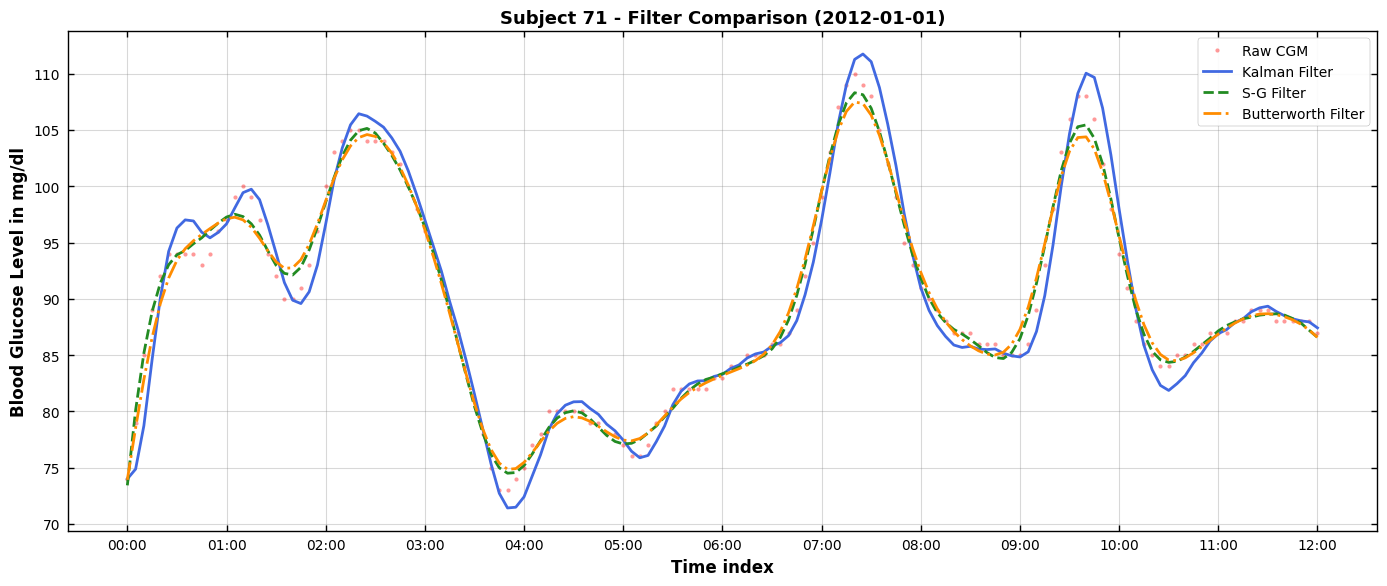

Comparison plot for Subject 71 generated.


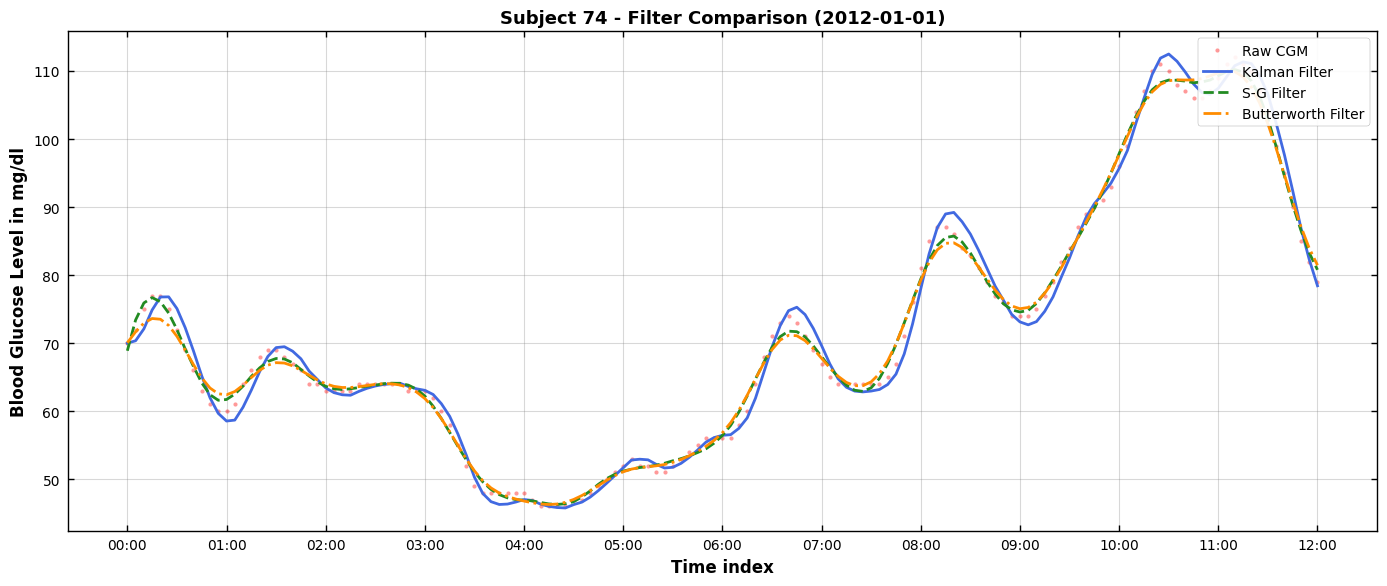

Comparison plot for Subject 74 generated.


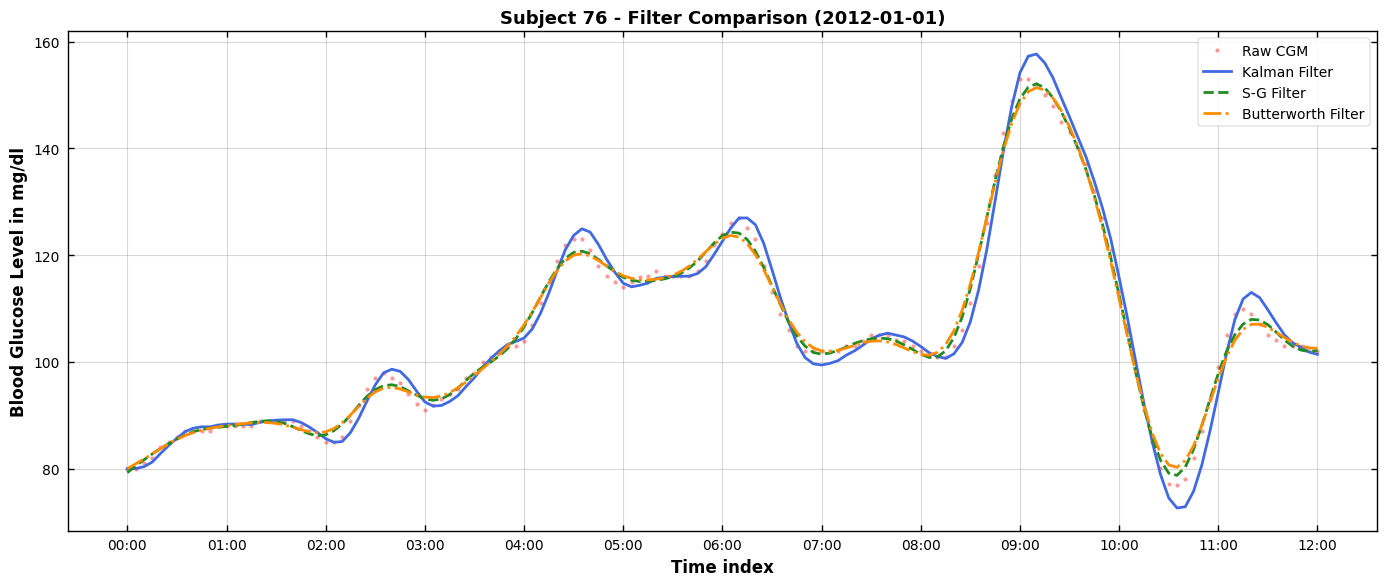

Comparison plot for Subject 76 generated.


In [10]:
# 可视化对比
# 选择前3个受试者进行展示
unique_subjects = sorted(merged_df['id'].unique())
subjects_to_plot = unique_subjects[50:60] # 与之前保持一致，查看 Subject 51 等

print(f"Generating comparison plots for {len(subjects_to_plot)} subjects")

for i, subject_id in enumerate(subjects_to_plot):
    subject_data = merged_df[merged_df['id'] == subject_id].copy()
    
    # 找到数据点最多的一天
    subject_data['date'] = subject_data['time'].dt.date
    if subject_data.empty:
        continue
        
    best_date = subject_data['date'].value_counts().idxmax()
    full_day_data = subject_data[subject_data['date'] == best_date].sort_values('time')
    
    # 截取12小时的数据进行展示
    if not full_day_data.empty:
        start_time = full_day_data['time'].iloc[0]
        end_time = start_time + pd.Timedelta(hours=12)
        plot_data = full_day_data[(full_day_data['time'] >= start_time) & (full_day_data['time'] <= end_time)]
    else:
        plot_data = full_day_data

    if plot_data.empty:
        continue
    
    # 创建图表
    plt.figure(figsize=(14, 6)) # 稍微宽一点以便展示图例
    
    # 1. 绘制原始数据 (红点, 稍微透明一点以免遮挡)
    plt.plot(plot_data['time'], plot_data['gl'], '.', color='red', markersize=6, alpha=0.4, label='Raw CGM')
    
    # 2. 绘制 Kalman 滤波 (蓝色实线)
    if 'gl_kalman' in plot_data.columns:
        plt.plot(plot_data['time'], plot_data['gl_kalman'], '-', color='royalblue', linewidth=2, label='Kalman Filter')
        
    # 3. 绘制 S-G 滤波 (绿色虚线)
    if 'gl_sg' in plot_data.columns:
        plt.plot(plot_data['time'], plot_data['gl_sg'], '--', color='forestgreen', linewidth=2, label='S-G Filter')
        
    # 4. 绘制 Butterworth 滤波 (橙色点划线)
    if 'gl_butter' in plot_data.columns:
        plt.plot(plot_data['time'], plot_data['gl_butter'], '-.', color='darkorange', linewidth=2, label='Butterworth Filter')
    
    # 设置标签和标题
    plt.ylabel('Blood Glucose Level in mg/dl', fontweight='bold')
    plt.xlabel('Time index', fontweight='bold')
    plt.title(f'Subject {subject_id} - Filter Comparison ({best_date})', fontweight='bold')
    
    # 设置图例
    plt.legend(loc='upper right', frameon=True, framealpha=0.9, edgecolor='gray')
    
    # 设置网格
    plt.grid(True, alpha=0.3, linestyle='-', color='gray')
    
    # 格式化时间轴
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    
    # 设置边框和刻度样式
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
        spine.set_color('black')
        
    plt.tick_params(direction='in', length=4, width=1, colors='black', top=True, right=True)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Comparison plot for Subject {subject_id} generated.")

## 观察与分析

通过对比图，你可以观察到：

1.  **Kalman Filter (蓝色)**: 通常非常平滑，对整体趋势跟踪很好，但可能会有轻微的滞后（取决于 Q/R 参数）。
2.  **S-G Filter (绿色)**: 在波峰和波谷处表现最好，能保留尖锐的生理变化（如餐后高血糖峰值），不会像其他滤波器那样把峰值“削平”。
3.  **Butterworth Filter (橙色)**: 非常平滑，去噪能力强，但如果截止频率设置不当，可能会丢失一些快速变化的细节。

根据你的具体需求（是更看重去噪效果，还是更看重保留峰值特征），选择最适合的预处理后的数据用于后续模型训练。